# Exploratory Data Analysis
**Dataset:** PaySim (6.3M synthetic mobile money transactions)

In [25]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Add project root to path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_data import (
    load_paysim,
    filter_fraud_types,
    get_data_quality_report,
)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('husl')

DATA_PATH        = PROJECT_ROOT / 'data' / 'raw' / 'paysim.csv'
EDA_PATH         = PROJECT_ROOT / 'data' / 'processed' / 'eda'           # figures, CSVs, JSONs
PREPROCESSING_PATH = PROJECT_ROOT / 'data' / 'processed' / 'preprocessing'  # parquets

EDA_PATH.mkdir(parents=True, exist_ok=True)
PREPROCESSING_PATH.mkdir(parents=True, exist_ok=True)

print(f'Project root      : {PROJECT_ROOT}')
print(f'Data path         : {DATA_PATH}')
print(f'Data exists       : {DATA_PATH.exists()}')
print(f'EDA output        : {EDA_PATH}')
print(f'Preprocessing out : {PREPROCESSING_PATH}')

Project root      : E:\Study\semester 4\mlops\project\fraud-detection-mlops
Data path         : E:\Study\semester 4\mlops\project\fraud-detection-mlops\data\raw\paysim.csv
Data exists       : True
EDA output        : E:\Study\semester 4\mlops\project\fraud-detection-mlops\data\processed\eda
Preprocessing out : E:\Study\semester 4\mlops\project\fraud-detection-mlops\data\processed\preprocessing


## 1.1 Data Loading

In [26]:
df = load_paysim(DATA_PATH, validate=True, verbose=True)


PAYSIM DATASET SUMMARY
Total rows:             6,362,620
Total columns:                 11
Memory usage:             1523.1 MB

Fraud transactions:         8,213  (0.1291%)
Legit transactions:     6,354,407  (99.8709%)

Transaction type distribution:
  CASH_OUT     2,237,500  (35.17%)  fraud: 4,116
  PAYMENT      2,151,495  (33.81%)  fraud: 0
  CASH_IN      1,399,284  (21.99%)  fraud: 0
  TRANSFER       532,909  (8.38%)  fraud: 4,097
  DEBIT           41,432  (0.65%)  fraud: 0

Unique sender accounts (nameOrig):    6,353,307
Unique receiver accounts (nameDest):  2,722,362
Step range: 1 – 743 (743 unique steps)

Amount statistics:
  count      6,362,620.00
  mean         179,861.90
  std          603,858.23
  min                0.00
  25%           13,389.57
  50%           74,871.94
  75%          208,721.48
  90%          365,423.31
  95%          518,634.20
  99%        1,615,979.47
  max       92,445,516.64

Null values: None



In [27]:
# # Saving quality report
# report = get_data_quality_report(df)
# with open(EDA_PATH / 'data_quality_report.json', 'w') as f:
#     json.dump(report, f, indent=2)
# print('Quality report saved.')
# print(json.dumps(report, indent=2))

Quality report saved.
{
  "total_rows": 6362620,
  "total_columns": 11,
  "memory_mb": 1523.13,
  "fraud_count": 8213,
  "fraud_rate_pct": 0.129082,
  "duplicate_rows": 0,
  "null_counts": {
    "step": 0,
    "type": 0,
    "amount": 0,
    "nameOrig": 0,
    "oldbalanceOrg": 0,
    "newbalanceOrig": 0,
    "nameDest": 0,
    "oldbalanceDest": 0,
    "newbalanceDest": 0,
    "isFraud": 0,
    "isFlaggedFraud": 0
  },
  "step_min": 1,
  "step_max": 743,
  "unique_steps": 743,
  "unique_orig_accounts": 6353307,
  "unique_dest_accounts": 2722362,
  "transaction_type_stats": {
    "PAYMENT": {
      "count": 2151495,
      "pct": 33.8146,
      "fraud_count": 0
    },
    "TRANSFER": {
      "count": 532909,
      "pct": 8.3756,
      "fraud_count": 4097
    },
    "CASH_OUT": {
      "count": 2237500,
      "pct": 35.1663,
      "fraud_count": 4116
    },
    "DEBIT": {
      "count": 41432,
      "pct": 0.6512,
      "fraud_count": 0
    },
    "CASH_IN": {
      "count": 1399284,
     

In [28]:
# Preview
df.head(3)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0


In [29]:
df.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

## 1.2 Exploratory Data Analysis
### 1.2.1 Class Distribution

Class Distribution
----------------------------------------
  Legitimate  :  6,354,407  (99.8709%)
  Fraud       :      8,213  (0.1291%)
  Imbalance ratio: 774:1


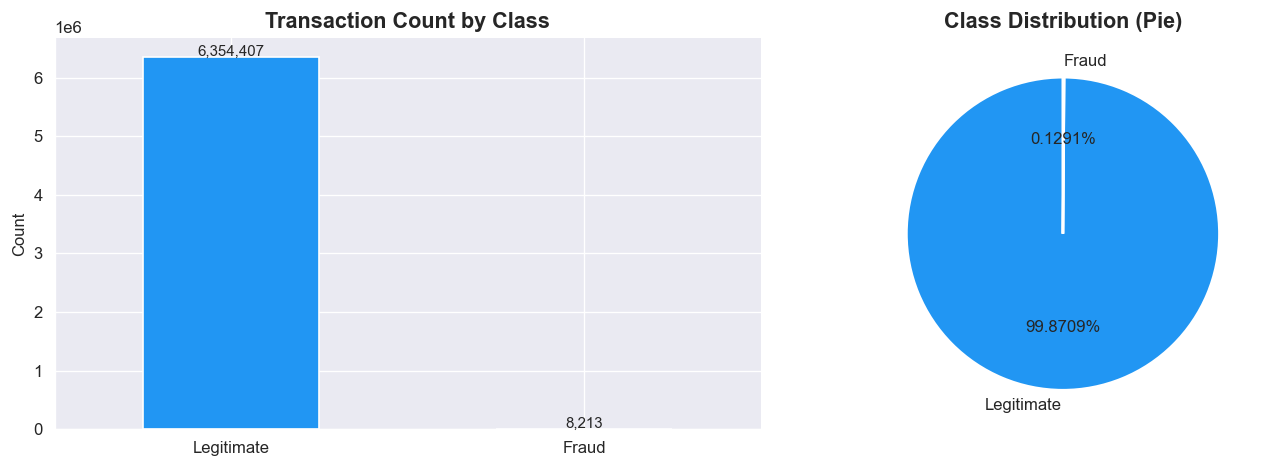

Extreme imbalance: 0.1291% fraud → motivates PR-AUC as primary metric


In [30]:
fraud_counts = df['isFraud'].value_counts().rename({0: 'Legitimate', 1: 'Fraud'})
fraud_pct = 100 * fraud_counts / len(df)

print('Class Distribution')
print('-' * 40)
for cls, cnt in fraud_counts.items():
    print(f'  {cls:<12}: {cnt:>10,}  ({fraud_pct[cls]:.4f}%)')
print(f'  Imbalance ratio: {fraud_counts["Legitimate"] / fraud_counts["Fraud"]:.0f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count bar
colors = ['#2196F3', '#F44336']
fraud_counts.plot(kind='bar', ax=axes[0], color=colors, rot=0)
axes[0].set_title('Transaction Count by Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('')
for i, (_, v) in enumerate(fraud_counts.items()):
    axes[0].text(i, v + len(df)*0.002, f'{v:,}', ha='center', fontsize=9)

# Percentage pie
axes[1].pie(
    fraud_counts.values, labels=fraud_counts.index,
    colors=colors, autopct='%1.4f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Class Distribution (Pie)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(EDA_PATH / 'fig_01_class_distribution.png', bbox_inches='tight')
plt.show()
print(f'Extreme imbalance: {fraud_pct["Fraud"]:.4f}% fraud → motivates PR-AUC as primary metric')

### 1.2.2 Transaction Type Analysis

In [31]:
type_stats = df.groupby('type').agg(
    count=('isFraud', 'count'),
    fraud_count=('isFraud', 'sum'),
).assign(
    fraud_rate_pct=lambda x: 100 * x['fraud_count'] / x['count'],
    share_pct=lambda x: 100 * x['count'] / len(df),
).sort_values('count', ascending=False)

print('Transaction Type Statistics')
print(type_stats.to_string())

type_stats.to_csv(EDA_PATH / 'type_stats.csv')

Transaction Type Statistics
            count  fraud_count  fraud_rate_pct  share_pct
type                                                     
CASH_OUT  2237500         4116        0.183955  35.166331
PAYMENT   2151495            0        0.000000  33.814608
CASH_IN   1399284            0        0.000000  21.992261
TRANSFER   532909         4097        0.768799   8.375622
DEBIT       41432            0        0.000000   0.651178


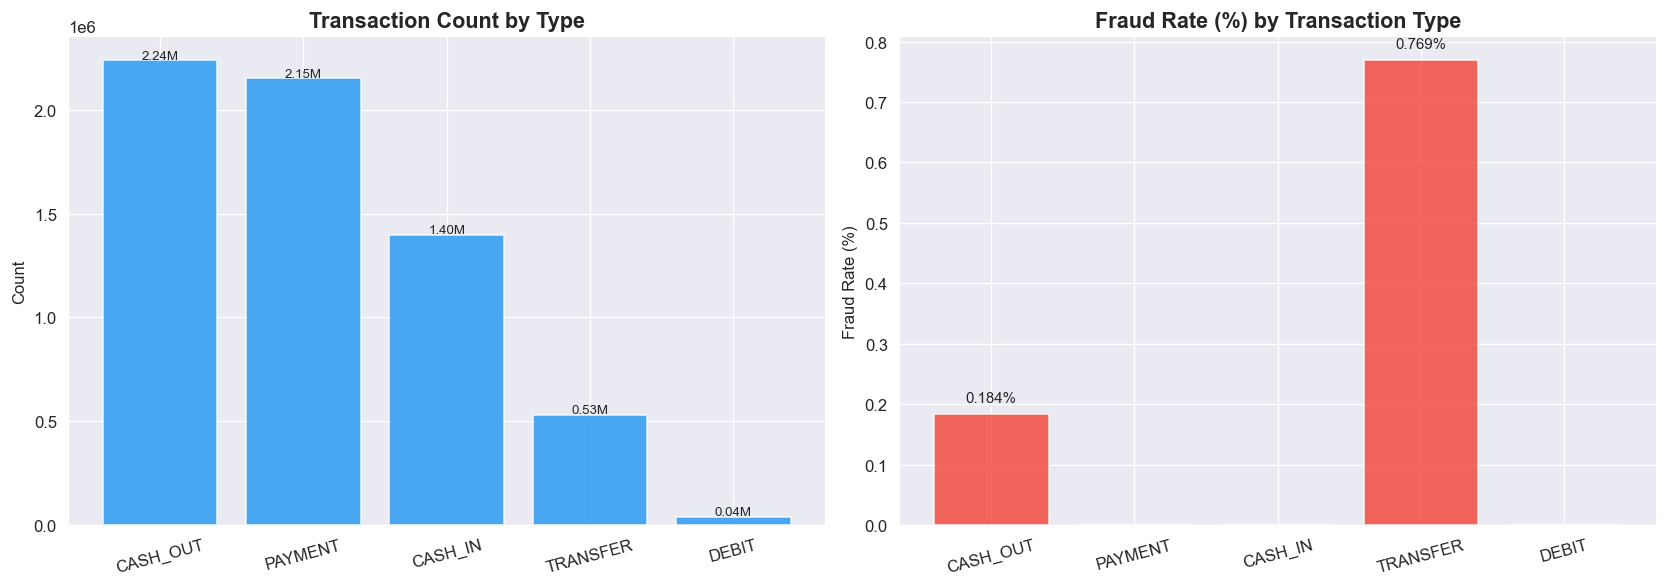

KEY FINDING: Only TRANSFER and CASH_OUT contain fraud — confirms filtering strategy


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction volume per type
type_order = type_stats.index.tolist()
axes[0].bar(type_order, type_stats['count'], color='#2196F3', alpha=0.8)
axes[0].set_title('Transaction Count by Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
for i, (t, row) in enumerate(type_stats.iterrows()):
    axes[0].text(i, row['count'] + len(df)*0.001, f"{row['count']/1e6:.2f}M", ha='center', fontsize=8)

# Fraud rate per type
fraud_colors = ['#F44336' if r > 0 else '#4CAF50' for r in type_stats['fraud_rate_pct']]
axes[1].bar(type_order, type_stats['fraud_rate_pct'], color=fraud_colors, alpha=0.8)
axes[1].set_title('Fraud Rate (%) by Transaction Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=15)
for i, (t, row) in enumerate(type_stats.iterrows()):
    if row['fraud_rate_pct'] > 0:
        axes[1].text(i, row['fraud_rate_pct'] + 0.02, f"{row['fraud_rate_pct']:.3f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(EDA_PATH / 'fig_02_transaction_types.png', bbox_inches='tight')
plt.show()
print('KEY FINDING: Only TRANSFER and CASH_OUT contain fraud — confirms filtering strategy')

### 1.2.3 Amount Analysis

In [33]:
fraud_mask = df['isFraud'] == 1
legit_mask = df['isFraud'] == 0

# Summary statistics
amount_stats = pd.DataFrame({
    'All': df['amount'].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]),
    'Fraud': df.loc[fraud_mask, 'amount'].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]),
    'Legitimate': df.loc[legit_mask, 'amount'].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]),
})
print('Amount Statistics by Class')
print(amount_stats.to_string())
amount_stats.to_csv(EDA_PATH / 'amount_stats.csv')

Amount Statistics by Class
                All         Fraud    Legitimate
count  6.362620e+06  8.213000e+03  6.354407e+06
mean   1.798619e+05  1.467967e+06  1.781970e+05
std    6.038582e+05  2.404253e+06  5.962370e+05
min    0.000000e+00  0.000000e+00  1.000000e-02
25%    1.338957e+04  1.270913e+05  1.336840e+04
50%    7.487194e+04  4.414234e+05  7.468472e+04
75%    2.087215e+05  1.517771e+06  2.083648e+05
90%    3.654233e+05  4.521724e+06  3.643734e+05
95%    5.186342e+05  8.006429e+06  5.156104e+05
99%    1.615979e+06  1.000000e+07  1.586064e+06
max    9.244552e+07  1.000000e+07  9.244552e+07


C:\Users\abdul14397\AppData\Local\Temp\ipykernel_5916\3033132227.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(plot_data, labels=['Legitimate', 'Fraud'], patch_artist=True, notch=False)
C:\Users\abdul14397\AppData\Local\Temp\ipykernel_5916\3033132227.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(EDA_PATH / 'fig_03_amount_analysis.png', bbox_inches='tight')
E:\Study\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


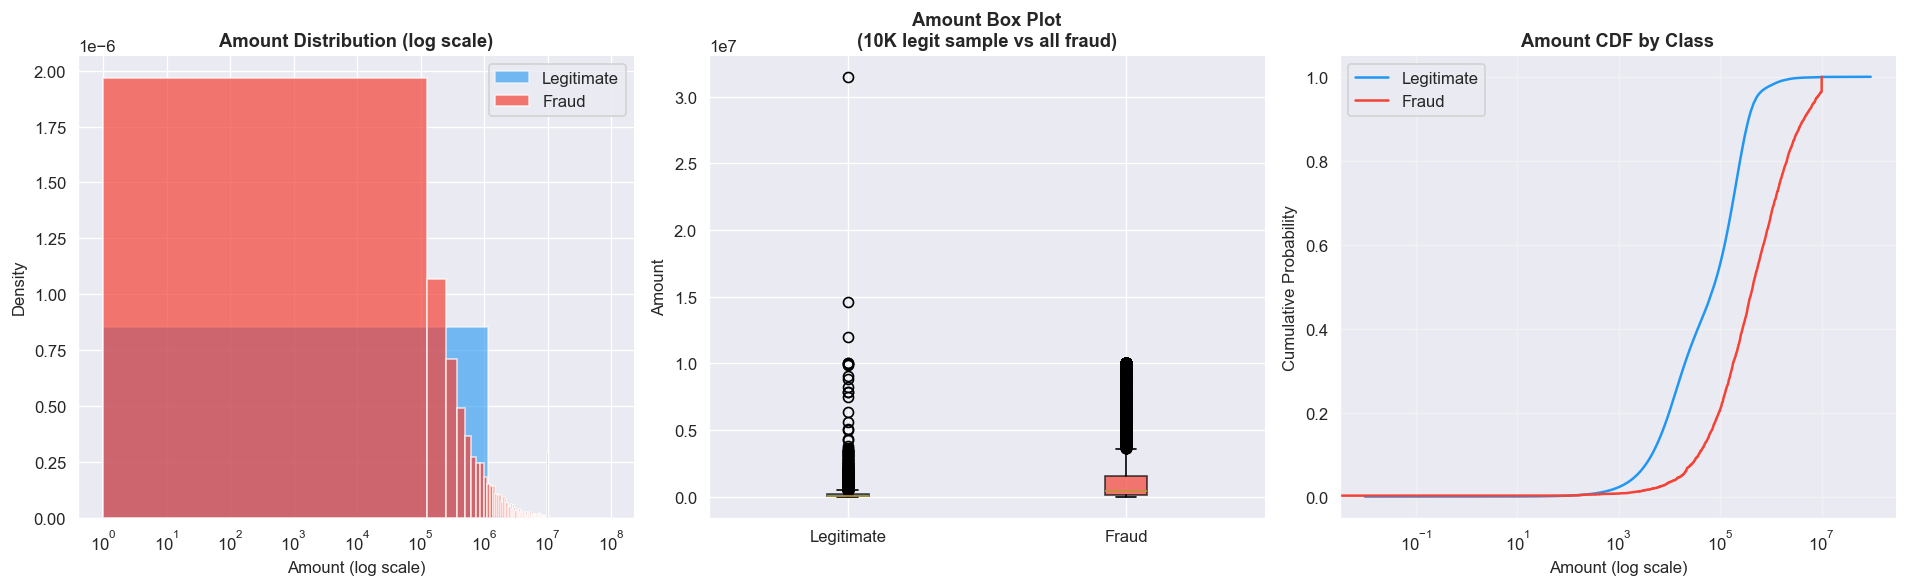

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Log-scale histogram
axes[0].hist(df.loc[legit_mask, 'amount'] + 1, bins=80, alpha=0.6, color='#2196F3', label='Legitimate', density=True)
axes[0].hist(df.loc[fraud_mask, 'amount'] + 1, bins=80, alpha=0.7, color='#F44336', label='Fraud', density=True)
axes[0].set_xscale('log')
axes[0].set_xlabel('Amount (log scale)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount Distribution (log scale)', fontsize=11, fontweight='bold')
axes[0].legend()

# Box plot
plot_data = [
    df.loc[legit_mask, 'amount'].sample(min(10000, legit_mask.sum()), random_state=42),
    df.loc[fraud_mask, 'amount'],
]
bp = axes[1].boxplot(plot_data, labels=['Legitimate', 'Fraud'], patch_artist=True, notch=False)
bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][1].set_facecolor('#F44336')
for patch in bp['boxes']:
    patch.set_alpha(0.7)
axes[1].set_ylabel('Amount')
axes[1].set_title('Amount Box Plot\n(10K legit sample vs all fraud)', fontsize=11, fontweight='bold')

# CDF
for mask, label, color in [(legit_mask, 'Legitimate', '#2196F3'), (fraud_mask, 'Fraud', '#F44336')]:
    data = np.sort(df.loc[mask, 'amount'].values)
    cdf = np.arange(1, len(data)+1) / len(data)
    axes[2].plot(data, cdf, label=label, color=color, linewidth=1.5)
axes[2].set_xscale('log')
axes[2].set_xlabel('Amount (log scale)')
axes[2].set_ylabel('Cumulative Probability')
axes[2].set_title('Amount CDF by Class', fontsize=11, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(EDA_PATH / 'fig_03_amount_analysis.png', bbox_inches='tight')
plt.show()

### 1.2.4 Temporal Analysis

In [35]:
# Transactions per step
txn_per_step = df.groupby('step').size().rename('txn_count')
fraud_per_step = df[fraud_mask].groupby('step').size().rename('fraud_count')
temporal_df = pd.concat([txn_per_step, fraud_per_step], axis=1).fillna(0)
temporal_df['fraud_rate'] = temporal_df['fraud_count'] / temporal_df['txn_count']

print(f'Total time steps: {len(temporal_df)}')
print(f'Steps with fraud: {(temporal_df["fraud_count"] > 0).sum()}')
print(f'Max transactions in a single step: {temporal_df["txn_count"].max():,}')
print(f'Peak fraud step: {temporal_df["fraud_count"].idxmax()} ({temporal_df["fraud_count"].max():.0f} fraud txns)')

Total time steps: 743
Steps with fraud: 741
Max transactions in a single step: 51,352
Peak fraud step: 212 (40 fraud txns)


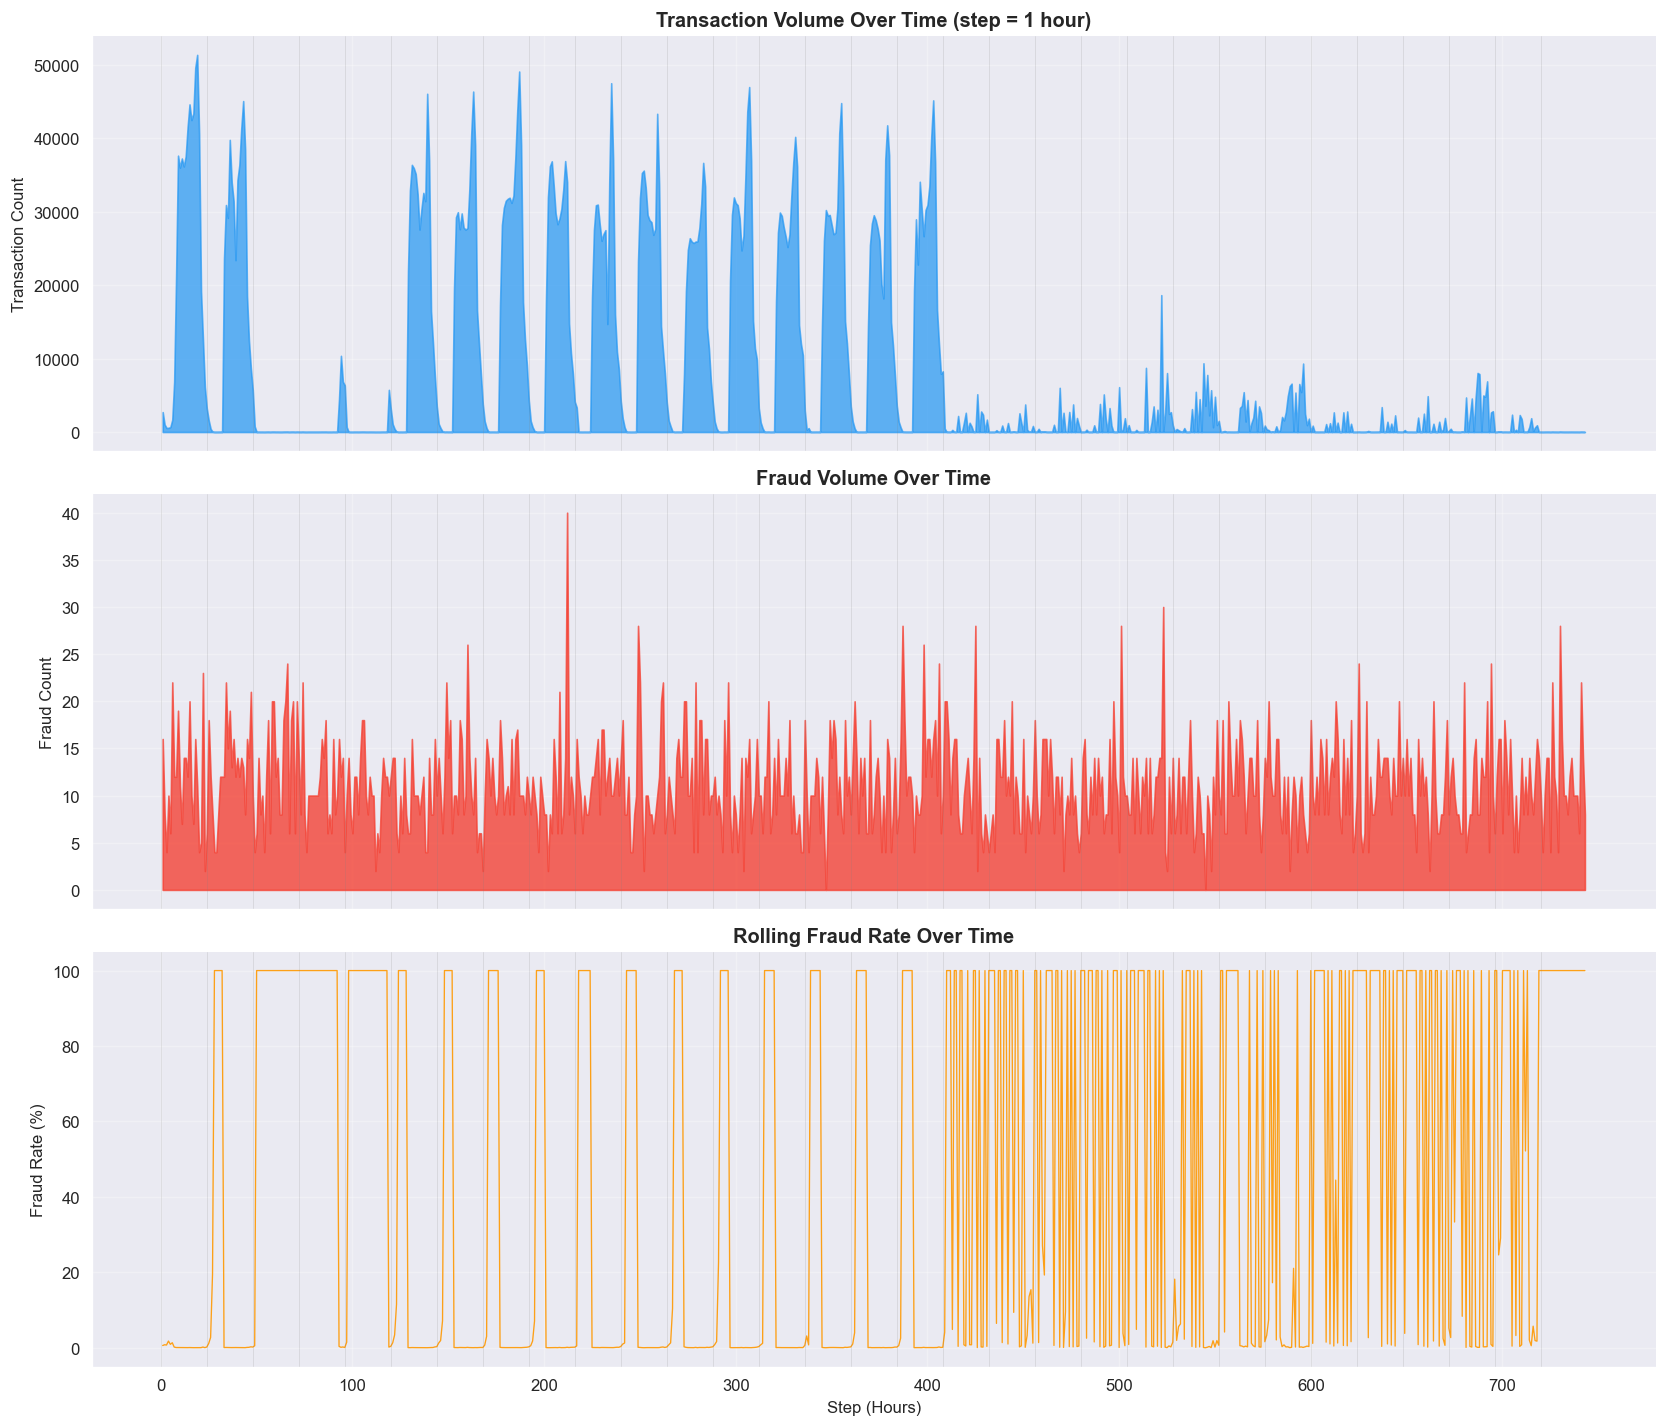

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].fill_between(temporal_df.index, temporal_df['txn_count'], alpha=0.7, color='#2196F3')
axes[0].set_ylabel('Transaction Count')
axes[0].set_title('Transaction Volume Over Time (step = 1 hour)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(temporal_df.index, temporal_df['fraud_count'], alpha=0.8, color='#F44336')
axes[1].set_ylabel('Fraud Count')
axes[1].set_title('Fraud Volume Over Time', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(temporal_df.index, temporal_df['fraud_rate'] * 100, color='#FF9800', linewidth=0.8, alpha=0.9)
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].set_xlabel('Step (Hours)')
axes[2].set_title('Rolling Fraud Rate Over Time', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# Mark day boundaries
for ax in axes:
    for day in range(0, int(temporal_df.index.max()), 24):
        ax.axvline(x=day, color='gray', alpha=0.2, linewidth=0.5)

plt.tight_layout()
plt.savefig(EDA_PATH / 'fig_04_temporal_analysis.png', bbox_inches='tight')
plt.show()

### 1.2.5 Balance Analysis

In [37]:
# Balance change vs amount for fraud transactions
fraud_txns = df[fraud_mask].copy()

fraud_txns['sender_balance_change'] = fraud_txns['oldbalanceOrg'] - fraud_txns['newbalanceOrig']
fraud_txns['balance_mismatch'] = np.abs(fraud_txns['sender_balance_change'] - fraud_txns['amount'])
fraud_txns['has_balance_mismatch'] = fraud_txns['balance_mismatch'] > 0.01

n_mismatch = fraud_txns['has_balance_mismatch'].sum()
print(f'Fraud transactions with sender balance mismatch: {n_mismatch:,} ({100*n_mismatch/len(fraud_txns):.2f}%)')

# Destination zero-balance analysis (known PaySim data quality issue)
zero_dest = ((df['oldbalanceDest'] == 0) & (df['newbalanceDest'] == 0))
print(f'\nDestination zero-balance (both old and new = 0):')
print(f'  All transactions:   {zero_dest.sum():,} ({100*zero_dest.mean():.2f}%)')
print(f'  Fraud transactions: {zero_dest[fraud_mask].sum():,} ({100*zero_dest[fraud_mask].mean():.2f}%)')
print(f'  Legit transactions: {zero_dest[legit_mask].sum():,} ({100*zero_dest[legit_mask].mean():.2f}%)')

Fraud transactions with sender balance mismatch: 45 (0.55%)

Destination zero-balance (both old and new = 0):
  All transactions:   2,317,282 (36.42%)
  Fraud transactions: 4,076 (49.63%)
  Legit transactions: 2,313,206 (36.40%)

NOTE: Destination balance reporting is unreliable in PaySim — this is documented


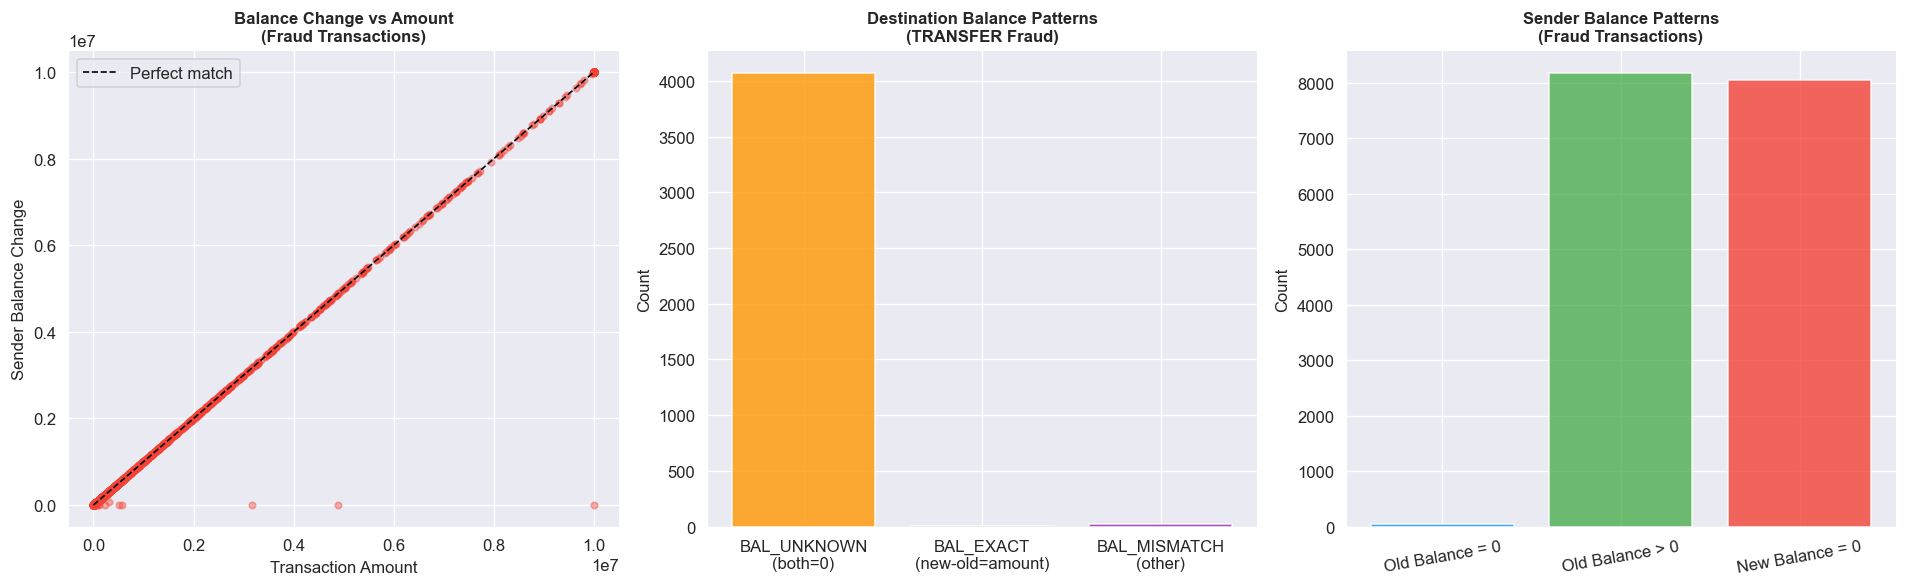

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Balance change vs amount scatter (fraud)
sample_fraud = fraud_txns.sample(min(2000, len(fraud_txns)), random_state=42)
axes[0].scatter(sample_fraud['amount'], sample_fraud['sender_balance_change'],
                alpha=0.4, s=15, color='#F44336')
lims = [0, sample_fraud[['amount', 'sender_balance_change']].max().max()]
axes[0].plot(lims, lims, 'k--', linewidth=1, label='Perfect match')
axes[0].set_xlabel('Transaction Amount')
axes[0].set_ylabel('Sender Balance Change')
axes[0].set_title('Balance Change vs Amount\n(Fraud Transactions)', fontsize=10, fontweight='bold')
axes[0].legend()

# Balance patterns in destination accounts for TRANSFER fraud
transfer_fraud = df[(df['type'] == 'TRANSFER') & fraud_mask]
dest_balance_patterns = pd.Series({
    'BAL_UNKNOWN\n(both=0)': int(((transfer_fraud['oldbalanceDest']==0) & (transfer_fraud['newbalanceDest']==0)).sum()),
    'BAL_EXACT\n(new-old=amount)': int((np.abs((transfer_fraud['newbalanceDest']-transfer_fraud['oldbalanceDest']) - transfer_fraud['amount']) < 0.01).sum()),
    'BAL_MISMATCH\n(other)': 0,
})
dest_balance_patterns['BAL_MISMATCH\n(other)'] = len(transfer_fraud) - dest_balance_patterns.sum()
dest_balance_patterns.clip(lower=0, inplace=True)

colors_bp = ['#FF9800', '#4CAF50', '#9C27B0']
axes[1].bar(dest_balance_patterns.index, dest_balance_patterns.values, color=colors_bp, alpha=0.8)
axes[1].set_title('Destination Balance Patterns\n(TRANSFER Fraud)', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Count')

# Sender balance: zero-origin fraud pattern
zero_old_orig = (fraud_txns['oldbalanceOrg'] == 0).sum()
zero_new_orig = (fraud_txns['newbalanceOrig'] == 0).sum()
nonzero_old = len(fraud_txns) - zero_old_orig
balance_cats = pd.Series({
    'Old Balance = 0': zero_old_orig,
    'Old Balance > 0': nonzero_old,
    'New Balance = 0': zero_new_orig,
})
axes[2].bar(balance_cats.index, balance_cats.values, color=['#2196F3', '#4CAF50', '#F44336'], alpha=0.8)
axes[2].set_title('Sender Balance Patterns\n(Fraud Transactions)', fontsize=10, fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig(EDA_PATH / 'fig_05_balance_analysis.png', bbox_inches='tight')
plt.show()

### 1.2.6 Receiver Account Analysis (Fraud-Specific)

In [39]:
# Unique receiver accounts in fraud transactions
fraud_receivers = df.loc[fraud_mask, 'nameDest'].unique()
all_receivers = df['nameDest'].unique()

print(f'Total unique receiver accounts:        {len(all_receivers):>10,}')
print(f'Fraud receiver accounts (nameDest):    {len(fraud_receivers):>10,}')
print(f'  = {100*len(fraud_receivers)/len(all_receivers):.4f}% of all receiver accounts')
print()

# How many fraud transactions per fraud receiver
fraud_txn_per_receiver = df.loc[fraud_mask].groupby('nameDest').size()
print('Fraud transactions per fraud receiver account:')
print(fraud_txn_per_receiver.describe())
print(f'Accounts with exactly 1 fraud txn:  {(fraud_txn_per_receiver==1).sum()} ({100*(fraud_txn_per_receiver==1).mean():.1f}%)')
print(f'Accounts with 2+ fraud txns:        {(fraud_txn_per_receiver>1).sum()}')

Total unique receiver accounts:         2,722,362
Fraud receiver accounts (nameDest):         8,169
  = 0.3001% of all receiver accounts

Fraud transactions per fraud receiver account:
count    8169.000000
mean        1.005386
std         0.073197
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         2.000000
dtype: float64
Accounts with exactly 1 fraud txn:  8125 (99.5%)
Accounts with 2+ fraud txns:        44


In [40]:
# Do fraud receivers also appear as senders?
fraud_receiver_set = set(fraud_receivers)
all_senders = set(df['nameOrig'].unique())
fraud_receivers_also_senders = fraud_receiver_set & all_senders
print(f'Fraud receivers that also appear as senders: {len(fraud_receivers_also_senders):,} ({100*len(fraud_receivers_also_senders)/len(fraud_receiver_set):.2f}%)')

Fraud receivers that also appear as senders: 18 (0.22%)
(These accounts have outgoing transactions too — model sees full behavioral profile)


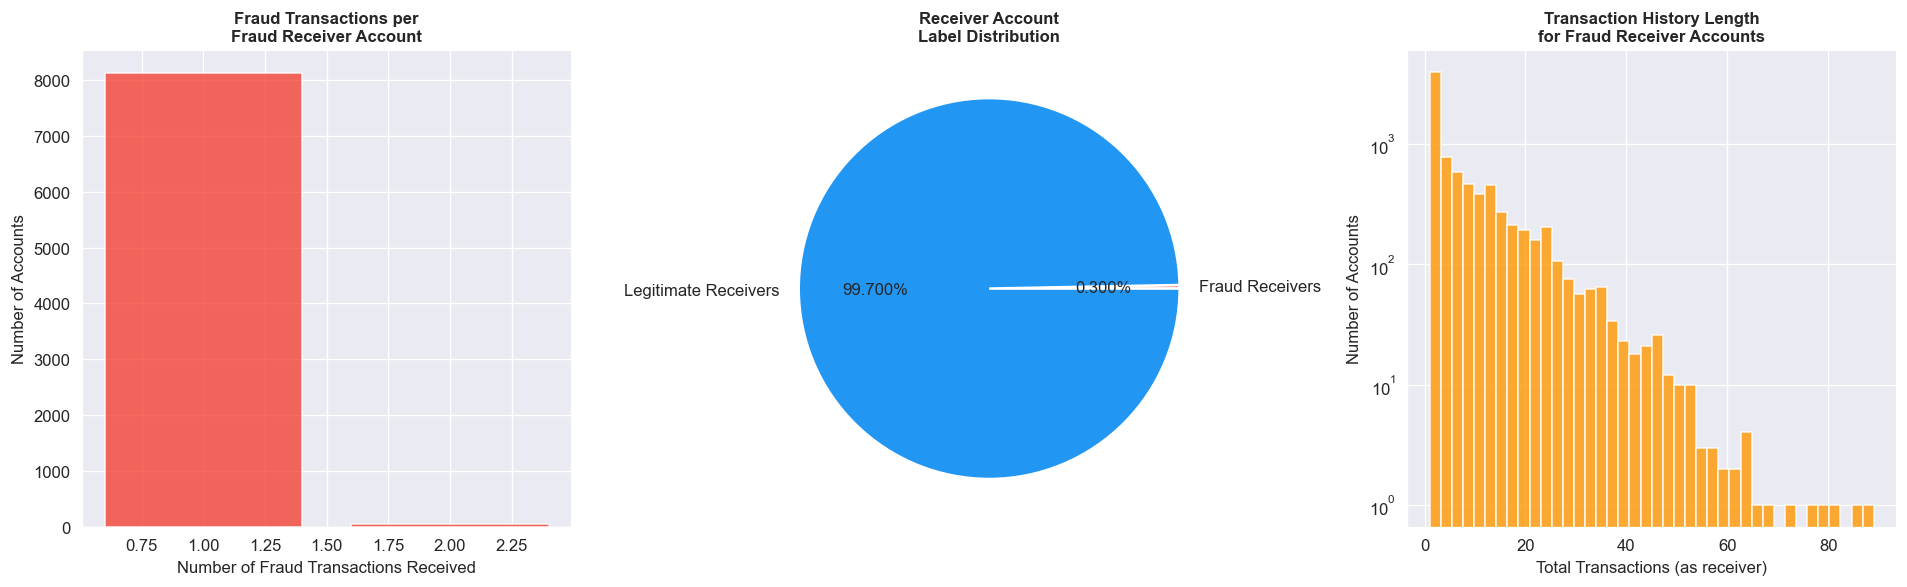

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution of fraud txns per fraud receiver
ax = axes[0]
counts = fraud_txn_per_receiver.value_counts().sort_index()
ax.bar(counts.index[:15], counts.values[:15], color='#F44336', alpha=0.8)
ax.set_xlabel('Number of Fraud Transactions Received')
ax.set_ylabel('Number of Accounts')
ax.set_title('Fraud Transactions per\nFraud Receiver Account', fontsize=10, fontweight='bold')

# Fraud vs legit receiver breakdown
ax = axes[1]
labels = ['Fraud Receivers', 'Legitimate Receivers']
sizes = [len(fraud_receivers), len(all_receivers) - len(fraud_receivers)]
colors_pie = ['#F44336', '#2196F3']
ax.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.3f%%',
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Receiver Account\nLabel Distribution', fontsize=10, fontweight='bold')

# Total transactions per fraud receiver (log scale)
ax = axes[2]
all_txn_for_fraud_receivers = df[df['nameDest'].isin(fraud_receiver_set)].groupby('nameDest').size()
ax.hist(all_txn_for_fraud_receivers, bins=40, color='#FF9800', alpha=0.8, edgecolor='white')
ax.set_xlabel('Total Transactions (as receiver)')
ax.set_ylabel('Number of Accounts')
ax.set_title('Transaction History Length\nfor Fraud Receiver Accounts', fontsize=10, fontweight='bold')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(EDA_PATH / 'fig_06_receiver_analysis.png', bbox_inches='tight')
plt.show()

### 1.2.7 General Account Statistics

In [42]:
print('General Account Statistics')
print('=' * 50)
print(f'Unique sender accounts (nameOrig):   {df["nameOrig"].nunique():>10,}')
print(f'Unique receiver accounts (nameDest): {df["nameDest"].nunique():>10,}')

# Overlap: accounts appearing as both sender AND receiver
orig_set = set(df['nameOrig'].unique())
dest_set = set(df['nameDest'].unique())
both = orig_set & dest_set
print(f'Accounts appearing as BOTH sender and receiver: {len(both):>7,}')
print()

# Transactions per account (as sender)
txn_per_sender = df.groupby('nameOrig').size()
txn_per_receiver = df.groupby('nameDest').size()

print('Transactions per sender account:')
print(txn_per_sender.describe().to_string())
print()
print('Transactions per receiver account:')
print(txn_per_receiver.describe().to_string())

General Account Statistics
Unique sender accounts (nameOrig):    6,353,307
Unique receiver accounts (nameDest):  2,722,362
Accounts appearing as BOTH sender and receiver:   1,769

Transactions per sender account:
count    6.353307e+06
mean     1.001466e+00
std      3.832002e-02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00

Transactions per receiver account:
count    2.722362e+06
mean     2.337169e+00
std      4.549264e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.130000e+02


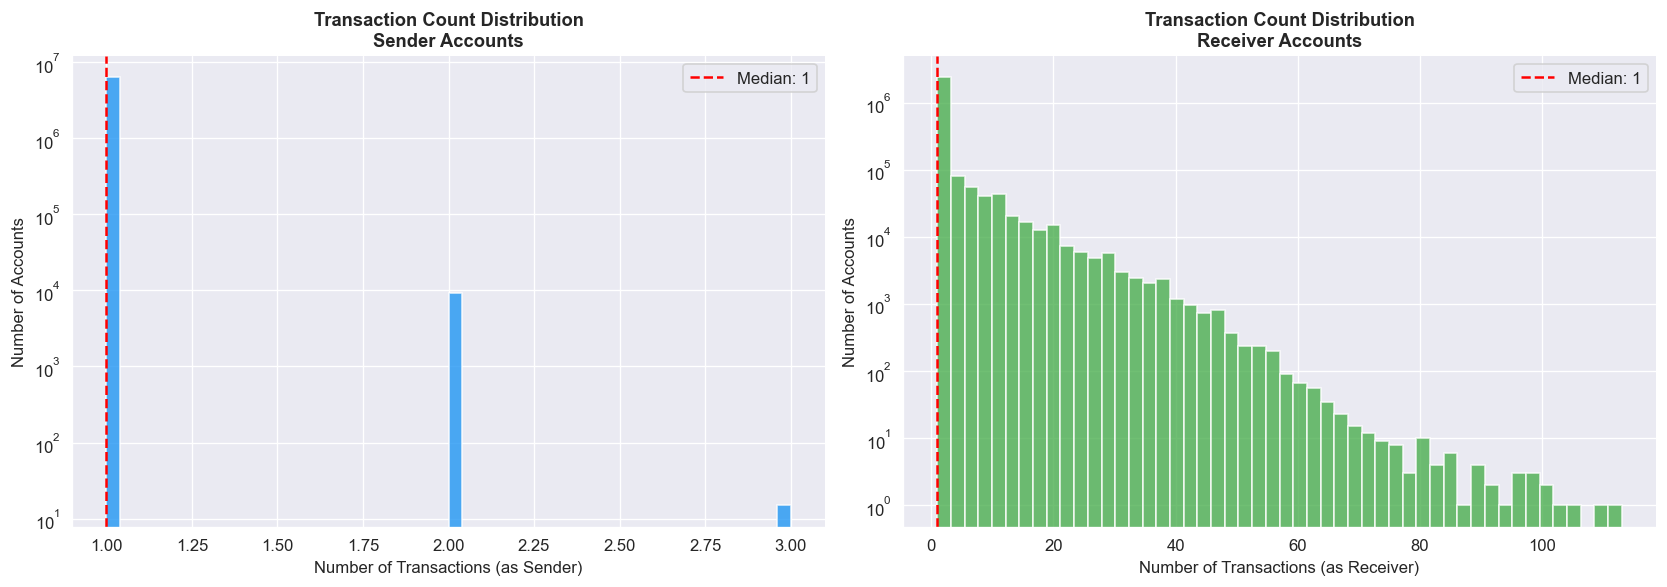

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transactions per sender
ax = axes[0]
ax.hist(txn_per_sender, bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
ax.set_xlabel('Number of Transactions (as Sender)')
ax.set_ylabel('Number of Accounts')
ax.set_title('Transaction Count Distribution\nSender Accounts', fontsize=11, fontweight='bold')
ax.set_yscale('log')
ax.axvline(txn_per_sender.median(), color='red', linestyle='--', label=f'Median: {txn_per_sender.median():.0f}')
ax.legend()

# Transactions per receiver
ax = axes[1]
ax.hist(txn_per_receiver, bins=50, color='#4CAF50', alpha=0.8, edgecolor='white')
ax.set_xlabel('Number of Transactions (as Receiver)')
ax.set_ylabel('Number of Accounts')
ax.set_title('Transaction Count Distribution\nReceiver Accounts', fontsize=11, fontweight='bold')
ax.set_yscale('log')
ax.axvline(txn_per_receiver.median(), color='red', linestyle='--', label=f'Median: {txn_per_receiver.median():.0f}')
ax.legend()

plt.tight_layout()
plt.savefig(EDA_PATH / 'fig_07_account_statistics.png', bbox_inches='tight')
plt.show()

## 1.3 Data Filtering — TRANSFER + CASH_OUT Only

In [44]:
df_filtered, filter_stats = filter_fraud_types(df)

print('Filtering Statistics')
print('=' * 50)
print(f'Before: {filter_stats["before_rows"]:>10,} rows | Fraud rate: {filter_stats["before_fraud_rate_pct"]:.4f}%')
print(f'After:  {filter_stats["after_rows"]:>10,} rows | Fraud rate: {filter_stats["after_fraud_rate_pct"]:.4f}%')
print(f'Removed: {filter_stats["removed_rows"]:>9,} rows ({filter_stats["removed_pct"]}%)')
print(f'Fraud transactions preserved: {filter_stats["after_fraud_count"]:,} / {filter_stats["before_fraud_count"]:,}')
print(f'Unique dest accounts after: {filter_stats["after_unique_dest_accounts"]:,}')

with open(EDA_PATH / 'filter_stats.json', 'w') as f:
    json.dump(filter_stats, f, indent=2)
print('\nFilter stats saved.')

Filtering Statistics
Before:  6,362,620 rows | Fraud rate: 0.1291%
After:   2,770,409 rows | Fraud rate: 0.2965%
Removed: 3,592,211 rows (56.46%)
Fraud transactions preserved: 8,213 / 8,213
Unique dest accounts after: 509,565

Filter stats saved.


In [45]:
# Verify fraud is only in TRANSFER and CASH_OUT after filtering
assert set(df_filtered['type'].unique()) == {'TRANSFER', 'CASH_OUT'}, 'Other types present after filtering!'
assert df_filtered['isFraud'].sum() == df['isFraud'].sum(), 'Fraud count changed after filtering!'
print('Assertions passed: Only TRANSFER and CASH_OUT remain, all fraud preserved.')

Assertions passed: Only TRANSFER and CASH_OUT remain, all fraud preserved.


In [46]:
# Save filtered dataset for downstream phases (preprocessing notebook reads from here)
df_filtered.to_parquet(PREPROCESSING_PATH / 'paysim_filtered.parquet', index=False)
print(f'Saved filtered dataset: {len(df_filtered):,} rows → data/processed/preprocessing/paysim_filtered.parquet')

Saved filtered dataset: 2,770,409 rows → data/processed/preprocessing/paysim_filtered.parquet


## 1.4 EDA Summary — Key Findings

In [47]:
n_total = len(df)
n_fraud = int(df['isFraud'].sum())
n_filtered = len(df_filtered)
n_fraud_receivers = len(fraud_receivers)

findings = {
    'dataset': {
        'total_transactions': n_total,
        'fraud_transactions': n_fraud,
        'fraud_rate_pct': round(100*n_fraud/n_total, 6),
        'time_span_hours': int(df['step'].max()),
        'time_span_days': round(df['step'].max() / 24, 1),
    },
    'fraud_patterns': {
        'fraud_only_in_types': list(sorted(df[fraud_mask]['type'].unique())),
        'non_fraud_types': list(sorted(set(df['type'].unique()) - set(df[fraud_mask]['type'].unique()))),
        'fraudulent_receiver_accounts': n_fraud_receivers,
        'pct_receivers_are_fraudulent': round(100*n_fraud_receivers/len(all_receivers), 4),
        'fraud_receivers_also_senders_pct': round(100*len(fraud_receivers_also_senders)/len(fraud_receiver_set), 2),
    },
    'balance_issues': {
        'dest_zero_balance_pct': round(100*zero_dest.mean(), 2),
        'dest_zero_balance_fraud_pct': round(100*zero_dest[fraud_mask].mean(), 2),
        'note': 'PaySim destination balance reporting is unreliable — BAL_UNKNOWN token handles this',
    },
    'after_filtering': {
        'rows': n_filtered,
        'removed_rows': n_total - n_filtered,
        'removed_pct': round(100*(n_total-n_filtered)/n_total, 2),
        'fraud_rate_pct': filter_stats['after_fraud_rate_pct'],
    },
    'phase_1_deliverables': {
        'eda_outputs': [
            'data/processed/eda/data_quality_report.json',
            'data/processed/eda/filter_stats.json',
            'data/processed/eda/type_stats.csv',
            'data/processed/eda/amount_stats.csv',
            'data/processed/eda/eda_findings.json',
            'data/processed/eda/fig_01_class_distribution.png',
            'data/processed/eda/fig_02_transaction_types.png',
            'data/processed/eda/fig_03_amount_analysis.png',
            'data/processed/eda/fig_04_temporal_analysis.png',
            'data/processed/eda/fig_05_balance_analysis.png',
            'data/processed/eda/fig_06_receiver_analysis.png',
            'data/processed/eda/fig_07_account_statistics.png',
        ],
        'preprocessing_inputs': [
            'data/processed/preprocessing/paysim_filtered.parquet',
        ],
    },
}

with open(EDA_PATH / 'eda_findings.json', 'w') as f:
    json.dump(findings, f, indent=2)

print('EDA KEY FINDINGS')
print('=' * 60)
print(f"1. EXTREME IMBALANCE: {findings['dataset']['fraud_rate_pct']:.4f}% fraud")
print(f"   → Motivates PR-AUC as primary metric, weighted BCE loss")
print()
print(f"2. FRAUD TYPE CONSTRAINT: Only TRANSFER + CASH_OUT contain fraud")
print(f"   → {n_total - n_filtered:,} rows removed ({100*(n_total-n_filtered)/n_total:.1f}%) without losing any fraud")
print()
print(f"3. RECEIVER-SIDE LABELING: {n_fraud_receivers:,} unique fraudulent receiver accounts")
print(f"   = {100*n_fraud_receivers/len(all_receivers):.4f}% of all receiver accounts")
print()
print(f"4. BALANCE DATA QUALITY: {100*zero_dest.mean():.1f}% transactions have dest zero-balance")
print(f"   (fraud: {100*zero_dest[fraud_mask].mean():.1f}%) — BAL_UNKNOWN token explicitly handles this")
print()
print(f"5. TEMPORAL SPAN: {findings['dataset']['time_span_days']} days of hourly data")
print(f"   → Temporal split (70/15/15%) is appropriate")
print('=' * 60)
print(f'EDA outputs   → data/processed/eda/')
print(f'Next input    → data/processed/preprocessing/paysim_filtered.parquet')
print('All findings saved to data/processed/eda/eda_findings.json')

EDA KEY FINDINGS
1. EXTREME IMBALANCE: 0.1291% fraud
   → Motivates PR-AUC as primary metric, weighted BCE loss

2. FRAUD TYPE CONSTRAINT: Only TRANSFER + CASH_OUT contain fraud
   → 3,592,211 rows removed (56.5%) without losing any fraud

3. RECEIVER-SIDE LABELING: 8,169 unique fraudulent receiver accounts
   = 0.3001% of all receiver accounts

4. BALANCE DATA QUALITY: 36.4% transactions have dest zero-balance
   (fraud: 49.6%) — BAL_UNKNOWN token explicitly handles this

5. TEMPORAL SPAN: 31.0 days of hourly data
   → Temporal split (70/15/15%) is appropriate
EDA outputs   → data/processed/eda/
Next input    → data/processed/preprocessing/paysim_filtered.parquet
All findings saved to data/processed/eda/eda_findings.json
